In [5]:
import sys, os
src_path = "../../"
sys.path.append(src_path)

import numpy as np
from src.foresee import Foresee, Utility, Model
from matplotlib import pyplot as plt

In [9]:
energy = "13.6"
modelname="MFC"
model = Model(modelname, path="./")

In [ ]:
generators = ['EPOSLHC'] # For now
model.add_production_3bodydecay(
    label= "211",
    pid0 = "211",
    pid1 = "-13",
    pid2 = "14",
    br = None,
    generator = generators,
    energy = energy,
    nsample = 1000,
    scaling = 0,
)

model.add_production_3bodydecay(
    label= "-211",
    pid0 = "-211",
    pid1 = "13",
    pid2 = "-14",
    br = None,
    generator = generators,
    energy = energy,
    nsample = 1000,
    scaling = 0,
)

model

In [21]:
# TODO: Add production/decay mechanisms...
# model.add_production_3bodydecay()

model.set_ctau_1d(
    filename="model/ctau.txt"
)

decay_modes = ["gamma_gamma", "mu_mu", "e_e"]
model.set_br_1d(
    modes = decay_modes,
    finalstates=[[22, 22], [13, -13], [11, -11]],
    filenames= [f"model/br/{mode}.txt" for mode in decay_modes]
)


In [22]:
foresee = Foresee(path=src_path)
foresee.set_model(model=model)

In [23]:
# I can't do this cuz... I haven't set up the model yet?
mass, coupling, = 0.0573, 3e-5
# plot=foresee.get_llp_spectrum(mass=mass, coupling=1, do_plot=True)
# plot.savefig("Spectrum_"+modelname+".pdf")
# plot.show()

In [24]:
foresee.set_detector(
    distance=620, 
    selection="np.sqrt((x.x)**2 + (x.y)**2)<1",    
    length=10, 
    luminosity=3000, 
)

In [26]:
setupnames = ["EPOSLHC"]
modes = { "211" : ["EPOSLHC"] }
momenta, weights, _ = foresee.write_events(
    mass = mass, 
    coupling = coupling, 
    energy = energy, 
    numberevent = 1000,
    filename = "model/events/test.hepmc", 
    return_data = True,
    weightnames=setupnames,
    modes=modes,
)

ValueError: Total of weights must be greater than zero

In [14]:
setups = [
    ["13.6TeV_FASER_EPOSLHC.npy", "EPOS", "red", "solid", 0, 3]
]

In [15]:
bounds = [
    # ["bounds_2207.08990.txt", "Something", 0, 0, 0]
    ]

In [16]:
projections = [
    # ["projections_SpinQuest_2212.00033.txt", "teal", "SeaQuest", 0, 0, 0 ]
]

In [ ]:
branchings = [
    ["e_e",         "red"          , "solid" , r"ee"               , 0.050, 0.60],
    ["gamma_gamma", "orange"       , "solid" , r"$\mu\mu$"         , 0.170, 0.10],
    ["mu_mu",       "blue"         , "solid" , r"$\pi^+\pi^-$"     , 0.225, 0.05],
]

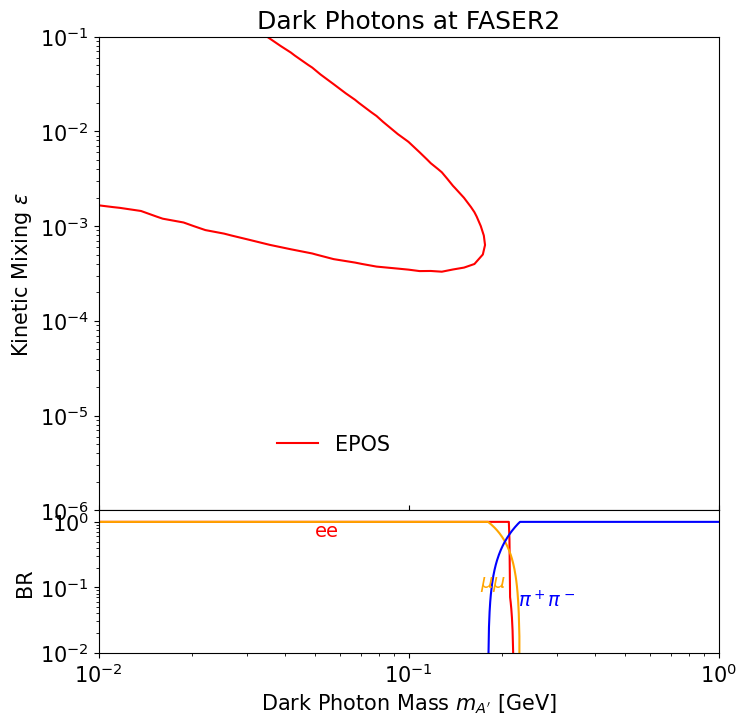

In [19]:
plot, ax, ax2 = foresee.plot_reach(
    setups=setups,
    bounds=bounds,
    bounds2=[],
    projections=projections,
    branchings=branchings,
    title="Dark Photons at FASER2", 
    xlims = [1e-2, 1e0], 
    ylims=[1e-6, 1e-1],
    xlabel=r"Dark Photon Mass $m_{A'}$ [GeV]", 
    ylabel=r"Kinetic Mixing $\epsilon$",
    legendloc=(0.5,0.2),
    figsize=(8,8),
)
